# Análise Exploratória do Open Weather

A ideia é criar um csv com as informações climáticas de vários estados dos EUA e criar um CSV com um mapa mostrando essas informações.

Essas informações serão adquiridas da api Open Weather. Esta api é paga, mas é possível acessar algumas partes dela gratuitamente.

Essa api foi escolhida pois oferece um tema mais interessante que o spotify e permite criar uma visualização de mapa, assim como visto em aula.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests
import time

%matplotlib inline

In [3]:
#Carregando as credenciais
cred = json.load(open('openweather.json'))
api_key = cred['key']

Para usar a API do Open Weather é necessário saber as coordenadas (Latitude e Longitude) de cada lugar. Para isso, eles oferecem outra API para essa consulta.

A API principal fornece vários dados como velocidade dos ventos, temperatura e etc...

Porém, a API principal não oferece dados históricos, apenas instantâneos, portanto só foi possível pegar um dado para cada localização.

In [6]:
# Api URLs
geolocation_api_call = "http://api.openweathermap.org/geo/1.0/direct?q={city_name},{state_code},US&limit=1&appid={api_key}"
geolocation_api_call = geolocation_api_call.replace('{api_key}', api_key)

weather_api_call = "http://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&exclude=minutely,hourly&units=metric&appid={api_key}"
weather_api_call = weather_api_call.replace('{api_key}', api_key)

Agora vamos preparar as infromações sobre localização

In [19]:
#Informações dos Estados dos EUA para gerar um mapa.
states_abbreviation = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
}

capital_dic={
    'Alabama': 'Montgomery',
    'Alaska': 'Juneau',
    'Arizona':'Phoenix',
    'Arkansas':'Little Rock',
    'California': 'Sacramento',
    'Colorado':'Denver',
    'Connecticut':'Hartford',
    'Delaware':'Dover',
    'Florida': 'Tallahassee',
    'Georgia': 'Atlanta',
    'Hawaii': 'Honolulu',
    'Idaho': 'Boise',
    'Illinois': 'Springfield',
    'Indiana': 'Indianapolis',
    'Iowa': 'Des Moines',
    'Kansas': 'Topeka',
    'Kentucky': 'Frankfort',
    'Louisiana': 'Baton Rouge',
    'Maine': 'Augusta',
    'Maryland': 'Annapolis',
    'Massachusetts': 'Boston',
    'Michigan': 'Lansing',
    'Minnesota': 'St. Paul',
    'Mississippi': 'Jackson',
    'Missouri': 'Jefferson City',
    'Montana': 'Helena',
    'Nebraska': 'Lincoln',
    'Nevada': 'Carson City',
    'New Hampshire': 'Concord',
    'New Jersey': 'Trenton',
    'New Mexico': 'Santa Fe',
    'New York': 'Albany',
    'North Carolina': 'Raleigh',
    'North Dakota': 'Bismarck',
    'Ohio': 'Columbus',
    'Oklahoma': 'Oklahoma City',
    'Oregon': 'Salem',
    'Pennsylvania': 'Harrisburg',
    'Rhode Island': 'Providence',
    'South Carolina': 'Columbia',
    'South Dakota': 'Pierre',
    'Tennessee': 'Nashville',
    'Texas': 'Austin',
    'Utah': 'Salt Lake City',
    'Vermont': 'Montpelier',
    'Virginia': 'Richmond',
    'Washington': 'Olympia',
    'West Virginia': 'Charleston',
    'Wisconsin': 'Madison',
    'Wyoming': 'Cheyenne',
    "District of Columbia": "Washington",
}

states_id = {'Alabama': 1, 
 'Alaska': 2, 
 'Arizona': 4, 
 'Arkansas': 5, 
 'California': 6, 
 'Colorado': 8, 
 'Connecticut': 9, 
 'Delaware': 10, 
 'District of Columbia': 11, 
 'Florida': 12, 
 'Georgia': 13, 
 'Hawaii': 15, 
 'Idaho': 16, 
 'Illinois': 17, 
 'Indiana': 18, 
 'Iowa': 19, 
 'Kansas': 20, 
 'Kentucky': 21, 
 'Louisiana': 22, 
 'Maine': 23, 
 'Maryland': 24, 
 'Massachusetts': 25, 
 'Michigan': 26, 
 'Minnesota': 27, 
 'Mississippi': 28, 
 'Missouri': 29, 
 'Montana': 30, 
 'Nebraska': 31, 
 'Nevada': 32, 
 'New Hampshire': 33, 
 'New Jersey': 34, 
 'New Mexico': 35, 
 'New York': 36, 
 'North Carolina': 37, 
 'North Dakota': 38, 
 'Ohio': 39, 
 'Oklahoma': 40, 
 'Oregon': 41, 
 'Pennsylvania': 42, 
 'Rhode Island': 44, 
 'South Carolina': 45, 
 'South Dakota': 46, 
 'Tennessee': 47, 
 'Texas': 48, 
 'Utah': 49, 
 'Vermont': 50, 
 'Virginia': 51, 
 'Washington': 53, 
 'West Virginia': 54, 
 'Wisconsin': 55, 
 'Wyoming': 56,
}

states = list(states_abbreviation.keys())


Usando um CSV com o nome de todas as cidades. O CSV foi retirado de: https://github.com/grammakov/USA-cities-and-states/blob/master/us_cities_states_counties.csv e renomeado para "USACities.csv".

In [8]:
cities_df = pd.read_csv('USACities.csv', sep='|')
# Após visualizar o arquivo, notei várias cidades repetidas e com City alias diferente, então removi elas.
cities_df = cities_df[(cities_df["State full"].isin(states)) & (cities_df['City'] == cities_df['City alias'])]
cities_df.head()

,City,State short,State full,County,City alias
1,Holtsville,NY,New York,SUFFOLK,Holtsville
2696,Agawam,MA,Massachusetts,HAMPDEN,Agawam
2697,Amherst,MA,Massachusetts,HAMPSHIRE,Amherst
2701,Barre,MA,Massachusetts,WORCESTER,Barre
2702,Belchertown,MA,Massachusetts,HAMPSHIRE,Belchertown


Aqui são feitas 2 consultas às APIs para cada cidade.

A partir da resposta da consulta, estamos selecionando as condições climáticas, temperatura, humidade e velocidade do vento.
Para todas as cidades, isso demorou 12 horas. Não execute isso a menos que tenha tempo pra esperar.

Escolhi coletar apenas os parâmetros temperatura, humidade e velocidade do vento. Outros parâmetros como pressão atmosférica, ângulo do vento e visibilidade, poderiam ter sido coletados, mas, com o objetivo de simplificar esse exercício, escolhi apenas esses 3.

In [64]:
pos = 0
data = []

In [ ]:
# Usando um try except para ignorar cidades que não tenham dados na API e/ou não seja possível obter os dados devido a erros de rede.
# Devido a quantidade de dados disponível, a perda de algumas cidades devido aos problemas supracitados não é um problema.
while pos < len(cities_df['City']):
    city = list(cities_df['City'])[pos]
    pos += 1
    state = cities_df[cities_df['City'] == city]['State full'].values[0]
    state_code = states_abbreviation[state]
    capital = (city == capital_dic[state])
    #print(f"State: {state}, City: {city}")
    geolocation_call = geolocation_api_call.replace('{city_name}', city).replace('{state_code}', state_code)
    try:
        lat, lon = requests.get(geolocation_call).json()[0]['lat'], requests.get(geolocation_call).json()[0]['lon']
        #print(f"Lat: {lat}, Lon: {lon}")
        weather_call = weather_api_call.replace('{lat}', str(lat)).replace('{lon}', str(lon))
        weather_data = requests.get(weather_call).json()
        #print(weather_data)
        data.append([city, state, state_code, capital, states_id[state],  weather_data['weather'][0]['main'], weather_data['main']['temp'], weather_data['main']['humidity'],  weather_data['wind']['speed']])
    except:
        # Printando as cidades onde não foi possível obter a localização ou dados do clima.
        print(f"State: {state}, City: {city}")
        time.sleep(0.5)


State: Massachusetts, City: Hanscom AFB
State: Massachusetts, City: Tyngsboro
State: Massachusetts, City: North Weymouth
State: Massachusetts, City: North Waltham
State: Massachusetts, City: Hyannis Port
State: Rhode Island, City: Peace Dale
State: New Hampshire, City: Mount Washington
State: New Hampshire, City: Gilmanton Iron Works
State: Maine, City: Orrs Island
State: Maine, City: China Village
State: Vermont, City: Mc Indoe Falls
State: Vermont, City: North Hartland
State: Vermont, City: Chester Depot
State: Vermont, City: Westminster Station
State: Vermont, City: Eden Mills
State: Vermont, City: Moretown
State: Vermont, City: Morrisville
State: Vermont, City: Moscow
State: Massachusetts, City: Northfield
State: Vermont, City: Northfield Falls
State: Vermont, City: North Hyde Park
State: Vermont, City: North Montpelier
State: Massachusetts, City: Plainfield
State: Massachusetts, City: Roxbury
State: Massachusetts, City: South Barre
State: Vermont, City: Waterbury
State: Vermont, C

In [65]:
# Garantindo que todas as capitais dos estados estão no dataset
# Essas cidades podem ter sido excluidas no passo anterior devido a instabilidades de rede.
# A existência desse passo exige que cidades repetidas sejam excluidas do dataset depois.
for state in states:
    city = capital_dic[state]
    state_code = states_abbreviation[state]
    capital = True
    #print(f"State: {state}, City: {city}")
    geolocation_call = geolocation_api_call.replace('{city_name}', city).replace('{state_code}', state_code)
    try:
        lat, lon = requests.get(geolocation_call).json()[0]['lat'], requests.get(geolocation_call).json()[0]['lon']
        #print(f"Lat: {lat}, Lon: {lon}")
        weather_call = weather_api_call.replace('{lat}', str(lat)).replace('{lon}', str(lon))
        weather_data = requests.get(weather_call).json()
        #print(weather_data)
        data.append([city, state, state_code, capital, states_id[state],  weather_data['weather'][0]['main'], weather_data['main']['temp'], weather_data['main']['humidity'],  weather_data['wind']['speed']])
    except:
        # Printando as cidades onde não foi possível obter a localização ou dados do clima.
        print(f"State: {state}, City: {city}")
        time.sleep(0.5)

Organizando o dataframe com cidade, estado, id do estado (para o gráfico de mapa) e as informações coletadas da API

In [31]:
df = pd.DataFrame(data, columns=['City', 'State', 'State Code', 'Is Capital', 'id', 'Weather', 'Temperature', 'Humidity', 'Wind Speed'])
df.head()

,City,State,State Code,Is Capital,id,Weather,Temperature,Humidity,Wind Speed
0,Montgomery,Alabama,AL,True,1,Clouds,7.43,49,2.06
1,Juneau,Alaska,AK,True,2,Snow,-4.00,86,0.00
2,Phoenix,Arizona,AZ,True,4,Clouds,9.16,32,1.54
3,Little Rock,Arkansas,AR,True,5,Rain,10.47,91,3.60
4,Sacramento,California,CA,True,6,Mist,4.55,95,1.54


In [81]:
# RRemovendo cidades duplicadas e salvando dataset
df = df.drop_duplicates('City', keep='last')
df.to_csv('weather_data.csv', index=False)

In [4]:
df = pd.read_csv('weather_data.csv')

In [84]:
print(len(df))

17952


Agrupando e tirando as médias por estado para gerar o quadro global do país.

In [5]:
df_by_state = df.groupby('State').agg({'State Code':'max','id':'max','Temperature': 'mean', 'Humidity': 'mean', 'Wind Speed': 'mean'}).reset_index()
df_by_state.head(15)

,State,State Code,id,Temperature,Humidity,Wind Speed
0,Alabama,AL,1,5.403820,58.140449,1.471910
1,Alaska,AK,2,-11.298844,77.578035,5.724971
2,Arizona,AZ,4,5.943602,30.372671,2.183913
3,Arkansas,AR,5,4.804314,76.190635,3.999231
4,California,CA,6,7.574673,74.947503,1.679949
5,Colorado,CO,8,-4.659574,78.611702,3.520372
6,Connecticut,CT,9,-1.848538,52.116959,4.231462
7,Delaware,DE,10,-2.271538,50.153846,4.866154
8,District of Columbia,DC,11,-2.470000,50.000000,4.120000
9,Florida,FL,12,10.516549,62.871537,2.423098


Visualização em mapa

In [6]:
import altair as alt
from vega_datasets import data

alt.themes.enable("dark")

states = alt.topo_feature(data.us_10m.url, 'states')

alt.Chart(states).mark_geoshape().encode(
    color=alt.Color('Temperature:Q', scale=alt.Scale(scheme='blues')),   # scale=color_scale
    stroke=alt.value('#154360')
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(df_by_state, 'id', list(df_by_state.columns))
).properties(
    width=500,
    height=300
).project(
    type='albersUsa'
)

C:\Users\rafac\AppData\Local\Temp\ipykernel_31232\3370837703.py:4: AltairDeprecationWarning: 
Deprecated since `altair=5.5.0`. Use altair.theme instead.
Most cases require only the following change:

    # Deprecated
    alt.themes.enable('quartz')

    # Updated
    alt.theme.enable('quartz')

If your code registers a theme, make the following change:

    # Deprecated
    def custom_theme():
        return {'height': 400, 'width': 700}
    alt.themes.register('theme_name', custom_theme)
    alt.themes.enable('theme_name')

    # Updated
    @alt.theme.register('theme_name', enable=True)
    def custom_theme():
        return alt.theme.ThemeConfig(
            {'height': 400, 'width': 700}
        )

See the updated User Guide for further details:
    https://altair-viz.github.io/user_guide/api.html#theme
    https://altair-viz.github.io/user_guide/customization.html#chart-themes
  alt.themes.enable("dark")


alt.Chart(...)

A partir das informações coletadas podemos efeturar uma análise estatística dos parâmetros coletados (temperatura, humidade e velocidade do vento) para analisar o clima em todo o país (EUA).

In [7]:
df.Temperature.describe()

count    17952.000000
mean        -2.000539
std          8.640158
min        -32.070000
25%         -7.540000
50%         -3.060000
75%          2.532500
max         24.860000
Name: Temperature, dtype: float64

<Axes: >

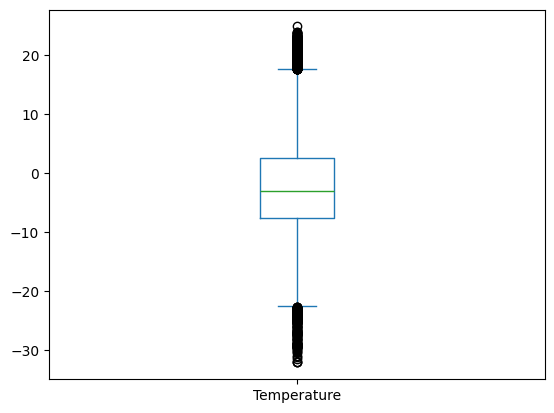

In [8]:
df.Temperature.plot(kind='box')

O gráfico anterior trás informações sobre o comportamento do parâmetro investigado (temperatura) no país inteiro, mas e se eu quiser saber desse parâmetro em uma cidade específica?

In [25]:
# Exemplo, quero saber a temperatura na capital do Texas
city = capital_dic['Texas']

print(df[df['City'] == city]["Temperature"])

17943    19.53
Name: Temperature, dtype: float64


O gráfico também mostra muitos ouliers, fica até difícil de ver. Podemos melhorar isso usando as médias por estado em vez de todas as temperaturas.

<Axes: >

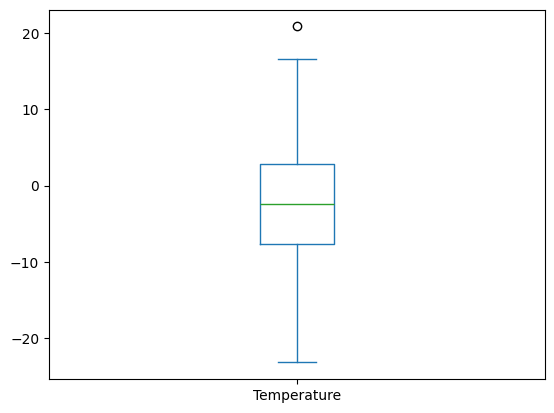

In [10]:
df_by_state.Temperature.plot(kind='box')

Ainda temos um outilier, mas a visualização desses outliers agora é muito mais fácil. Qual será esse outlier?

In [11]:
print(df_by_state[df_by_state['Temperature'] == df_by_state.Temperature.max()])

     State State Code  id  Temperature   Humidity  Wind Speed
11  Hawaii         HI  15    20.878889  81.694444    2.326944


Os gráficos até agora foram para analizar o país inteiro. E se eu quiser analizar apenas um estado?

<Axes: >

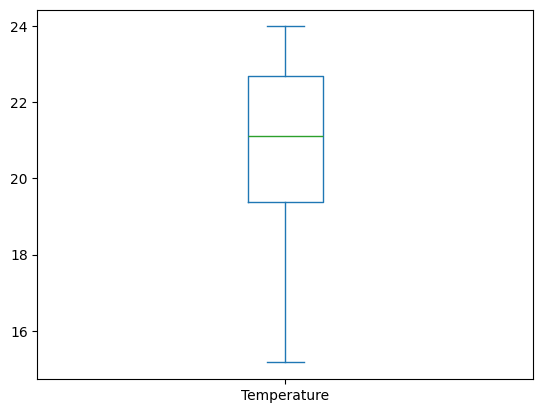

In [12]:
df[df["State"] == "Hawaii"].Temperature.plot(kind='box')

In [13]:
df[df["State"] == "Hawaii"].describe()

,id,Temperature,Humidity,Wind Speed
count,72.0,72.000000,72.000000,72.000000
mean,15.0,20.878889,81.694444,2.326944
std,0.0,2.206966,6.562031,1.287841
min,15.0,15.170000,66.000000,0.000000
25%,15.0,19.382500,77.000000,1.340000
50%,15.0,21.120000,80.000000,2.325000
75%,15.0,22.685000,85.250000,3.600000
max,15.0,23.980000,99.000000,4.180000


Sobre os parâmetros coletados, teriam eles alguma relação direta entre si?

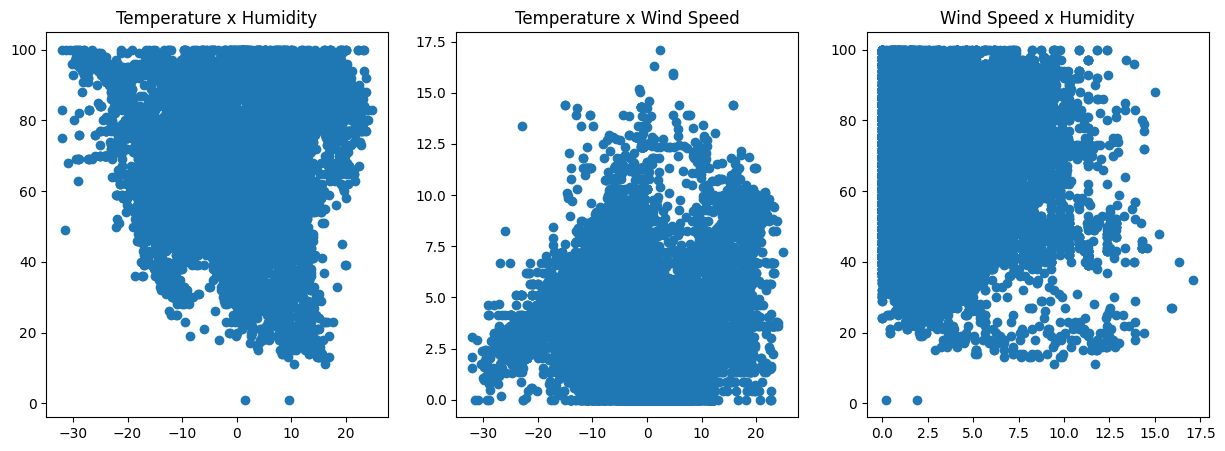

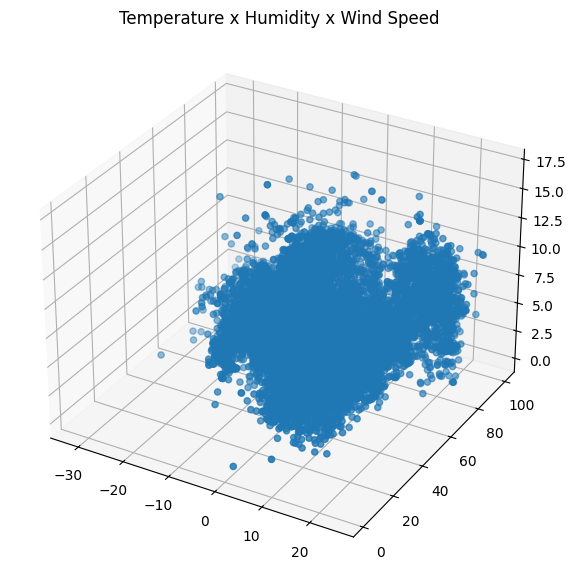

In [23]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(df.Temperature, df.Humidity, 'o')
plt.title('Temperature x Humidity')
plt.subplot(1,3,2)
plt.plot(df.Temperature, df["Wind Speed"], 'o')
plt.title('Temperature x Wind Speed')
plt.subplot(1,3,3)
plt.plot(df["Wind Speed"], df.Humidity, 'o')
plt.title('Wind Speed x Humidity')
plt.show()

fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
ax.scatter3D(df.Temperature, df.Humidity, df["Wind Speed"])
plt.title('Temperature x Humidity x Wind Speed')
plt.show()

Os gráficos acima mostram que não há quaisquer relações entre 2 ou entre todos os parâmetros. Isso pode ser causado pelo tamanho do país e da quantidade de dados, talvez essas relações apareçam se analizarmos em um espaço menor (por exemplo, apenas um estado).

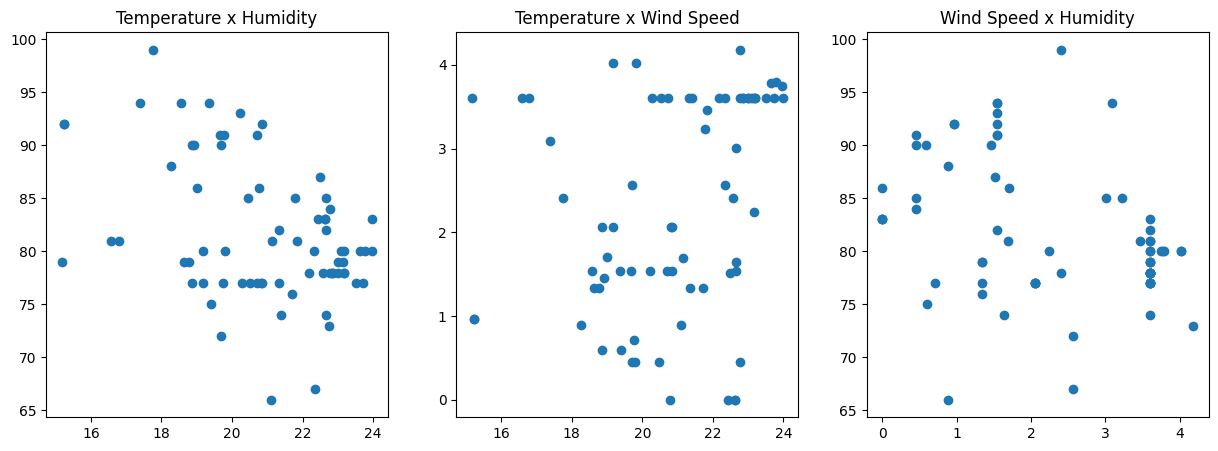

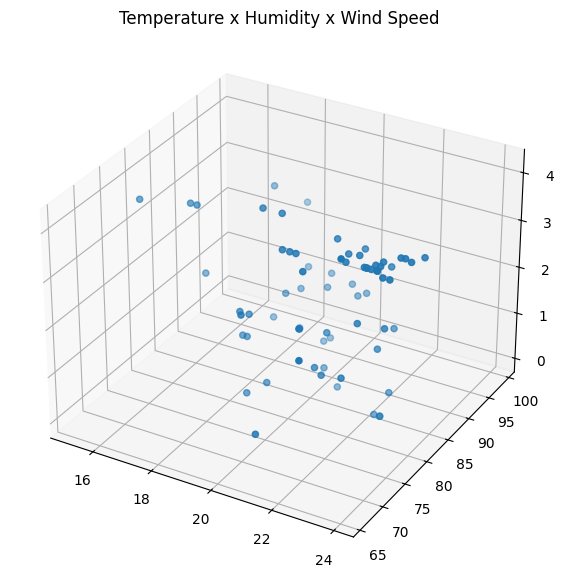

In [24]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(df[df["State"] == "Hawaii"].Temperature, df[df["State"] == "Hawaii"].Humidity, 'o')
plt.title('Temperature x Humidity')
plt.subplot(1,3,2)
plt.plot(df[df["State"] == "Hawaii"].Temperature, df[df["State"] == "Hawaii"]["Wind Speed"], 'o')
plt.title('Temperature x Wind Speed')
plt.subplot(1,3,3)
plt.plot(df[df["State"] == "Hawaii"]["Wind Speed"], df[df["State"] == "Hawaii"].Humidity, 'o')
plt.title('Wind Speed x Humidity')
plt.show()

fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
ax.scatter3D(df[df["State"] == "Hawaii"].Temperature, df[df["State"] == "Hawaii"].Humidity, df[df["State"] == "Hawaii"]["Wind Speed"])
plt.title('Temperature x Humidity x Wind Speed')
plt.show()

Ficou claro que, mesmo em um único estado, não há uma correlação direta entre os parâmetros analizados.

## Conclusões

Este dataset trás muitas informações interessantes, mas, a falta de dados temporais impede a realização de uma análise do comportamento desses parâmetros. Porém, uma análise desses parâmetro por região ainda é muito interessante.

Quanto ao dashboard, o mapa mostrando a média das temperaturas por estado é a meneria mais simples de fazer uma análise superficial de um parâmetro, já o box plot permite uma análise estatísca desses valores. Com 2 gráficos desses para cada parâmetro, é melhor para o usuário analizá-los individualmente. Ao permitir que o usuário selecione em qual estado e (ou) cidade ele está interessado, podemos gerar mais um box plot, mostrando apenas as informações do estado selecionado. Uma vez que estamos falando de clima, é interessante mostar ao usuário qual a condição climática do local (Chuva, neve, limpo, etc...), esse valor, por não ser numérico, precisará ficar em uma tabela. Por fim, o dashboard precisa, também, mostrar a média do país, do estado e o valor da cidade selecionada, de acordo com as seleções do usuário, usando o st.metric com o delta sendo calculado em cima da média do estado ou país (dependendo da seleção), permite mostrar esses valores de forma menos repetitiva.

Em resumo, usando a API do OpenWeather foi possivel montar um dataset muito interessante com informações climáticas de cidades dos EUA. Infelizmente esses dados não trazem muitas informações temporais, então não consegui pensar em muitos gráficos para mostrar aqui, mas a quantidade de informação obtida (os dados climáticos da maioria das cidades em todos os estados no continente principal dos EUA mais Alaska e Hawaii), compensa, em minha opinião, a falta desses dados temporais, no contexto deste exercício. O dashboard construido dá uma visão geral sobre o clima dos EUA entre noite de 4/1/25 e a madrugada de 5/1/25 e permite a visualização dos parâmetros analizados tanto em contexto nacional quanto nos contextos estadual e local.